In [1]:
import pandas as pd
import numpy as np
import glob
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
archivos = glob.glob("src/data/groups/*.json")
complete_df = pd.DataFrame()
for archivo in archivos:
   df = pd.read_json(archivo)
   complete_df = pd.concat([complete_df, df], ignore_index=True)

In [3]:
# Eliminamos las columnas que no se van a usar
clean_df = complete_df.drop(["max_playtime", "trading", "min_playtime", "description", "num_of_weights", "family"], axis=1)

In [35]:
# Filtramos los datos
clean_df = clean_df[clean_df["num_of_ratings"] >= 30]
clean_df = clean_df[clean_df["weight"] > 0]
clean_df = clean_df[clean_df["average_rating"] > 0]
clean_df = clean_df[clean_df["playingtime"] > 0]
clean_df = clean_df[clean_df["min_players"] > 0]
clean_df = clean_df[clean_df["min_players"] > 0]
clean_df = clean_df[clean_df["max_players"] < 30]
# Y nos quedamos solo con los juegos 

games_df = clean_df[clean_df["type"] == "boardgame"]


In [36]:
games_df.describe()

,row_id,min_players,max_players,playingtime,minimum_age,release_year,average_rating,num_of_ratings,weight,bayes_average,std_deviation,owned,wanting,wishing
count,28873.000000,28873.000000,28873.000000,28873.000000,28873.000000,28873.000000,28873.000000,28873.000000,28873.000000,28873.000000,28873.000000,28873.000000,28873.000000,28873.000000
mean,177512.011776,1.938939,4.684169,94.962179,9.825027,1996.499879,6.522383,1009.436394,1.986384,5.679178,1.532139,1844.280677,39.463998,287.588578
std,143318.879493,0.690035,2.467248,684.978968,3.524516,170.614965,0.916022,4428.025956,0.789953,0.354762,0.298080,6933.739440,105.736284,997.197001
min,1.000000,1.000000,0.000000,1.000000,0.000000,-3500.000000,1.177420,30.000000,1.000000,3.689310,0.440836,2.000000,0.000000,0.000000
25%,23928.000000,2.000000,4.000000,30.000000,8.000000,2005.000000,5.957140,61.000000,1.333300,5.510720,1.330450,166.000000,3.000000,18.000000
50%,171908.000000,2.000000,4.000000,45.000000,10.000000,2015.000000,6.552120,140.000000,1.933300,5.542160,1.487060,376.000000,9.000000,51.000000
75%,298596.000000,2.000000,6.000000,90.000000,12.000000,2020.000000,7.131530,457.000000,2.500000,5.666000,1.678450,1102.000000,29.000000,165.000000
max,466729.000000,9.000000,28.000000,84000.000000,23.000000,2027.000000,9.843750,142100.000000,4.817000,8.476900,4.323890,239917.000000,1977.000000,27010.000000


In [37]:
# Creamos la columna "popularidad_total" (también conocida como interés medio)
games_df["popularidad_total"] = (games_df["owned"] + games_df["wishing"])

### Gráfico de correlaciones para elegir las variables que se tendrán en cuenta para el diseño inicial de juego:

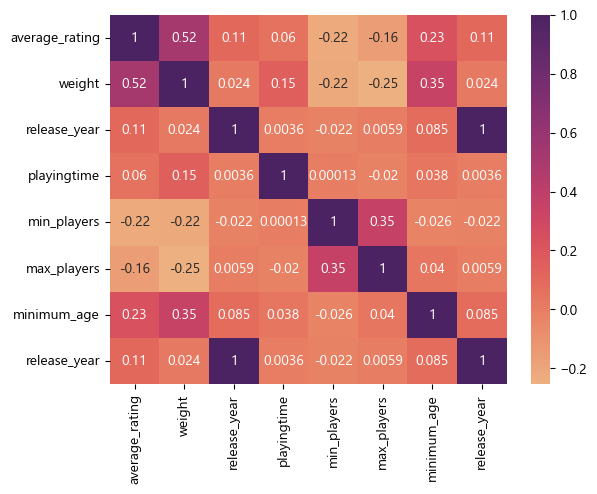

In [38]:
cols = ["average_rating", "weight", "release_year", "playingtime", "min_players", "max_players", "minimum_age", "release_year"]

corr = games_df[cols].corr()

sns.heatmap(corr, annot=True, cmap="flare")
plt.show()

### Correlación entre la valoración y el weight (complejidad) fuerte. Correlación débil entre el tiempo de juego y la complejidad. 

## Una vez filtrados, hacemos el análisis de las mecánicas y categorías

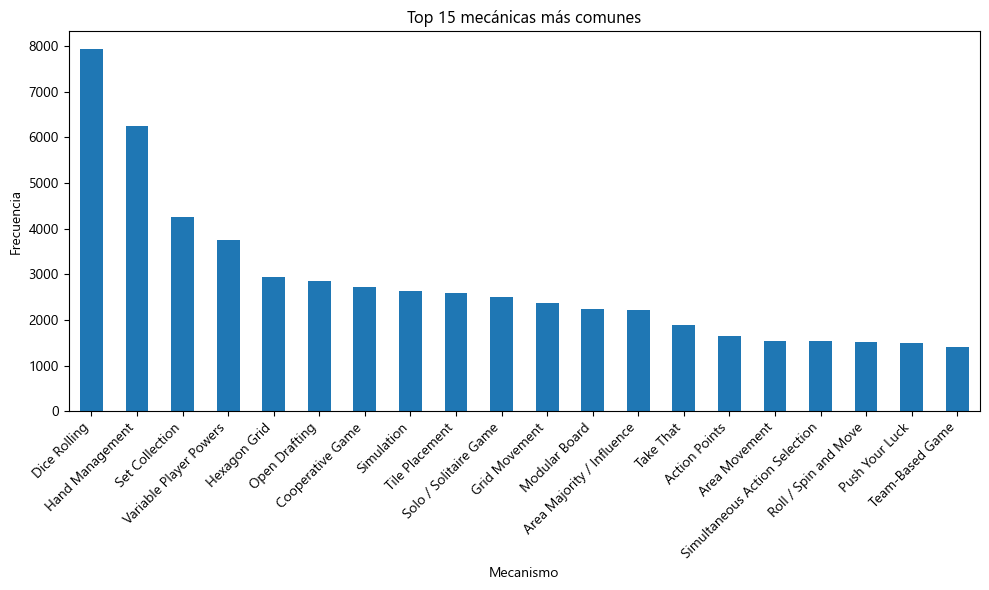

In [39]:
# Representación mecánicas más frecuentes:

df_mecha = games_df.explode("mechanisms")
num_mecha = df_mecha["mechanisms"].value_counts().head(20)

plt.figure(figsize=(10,6))
num_mecha.plot(kind="bar")

plt.title("Top 15 mecánicas más comunes")
plt.xlabel("Mecanismo")
plt.ylabel("Frecuencia")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

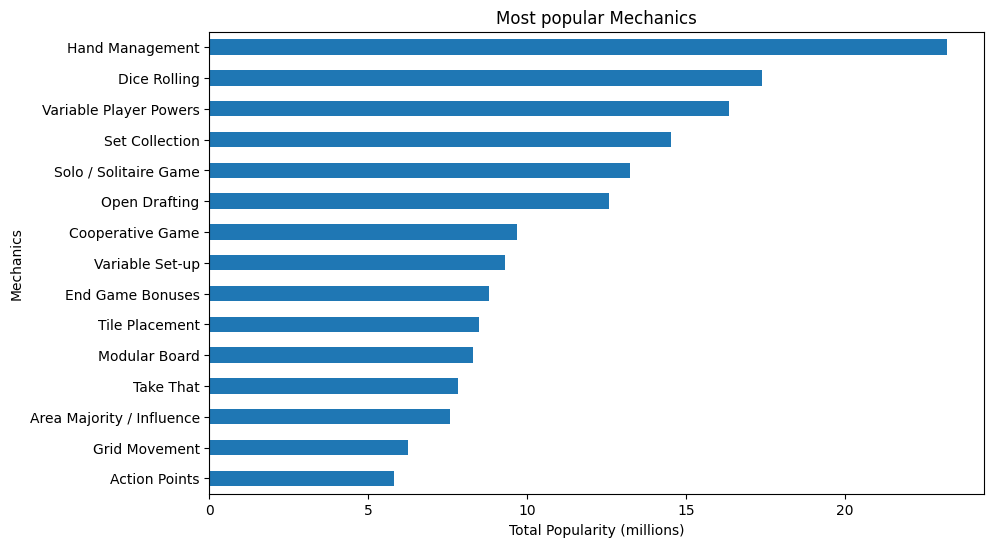

In [9]:
# Representación de las mecánicas en base a su popularidad:

top = games_df.explode("mechanisms").groupby("mechanisms")["popularidad_total"].sum().sort_values(ascending=False).head(15)/1000000

top.plot(kind="barh", figsize=(10,6))
plt.gca().invert_yaxis()
plt.title("Most popular Mechanics")
plt.xlabel("Total Popularity (millions)")
plt.ylabel("Mechanics")
plt.show()
plt.rcParams["font.family"] = "Segoe UI"

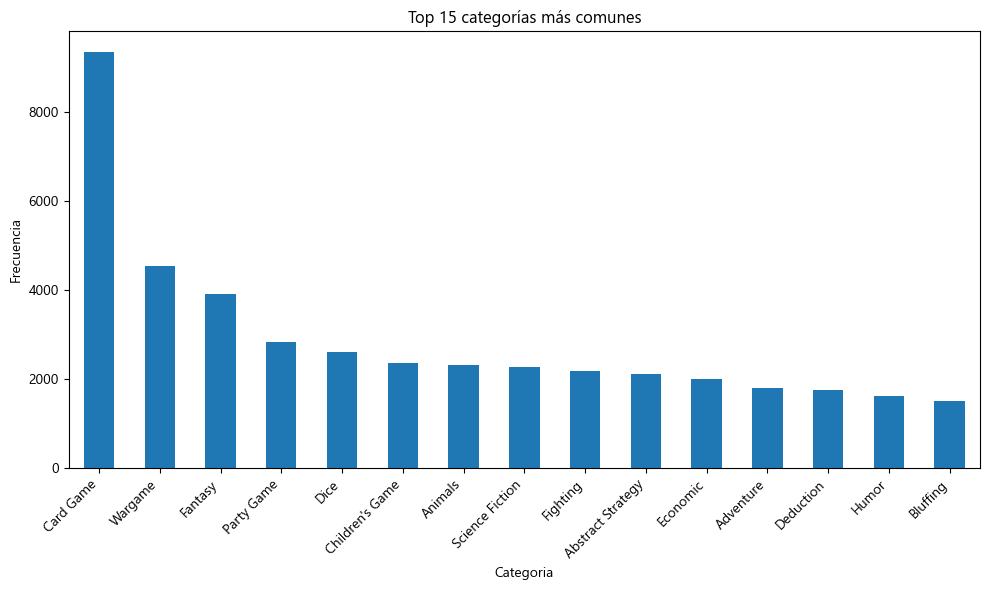

In [10]:
# Representación categorías más frecuentes
df_cat = games_df.explode("categories")
num_cat = df_cat["categories"].value_counts().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
num_cat.plot(kind="bar")

plt.title("Top 15 categorías más comunes")
plt.xlabel("Categoria")
plt.ylabel("Frecuencia")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

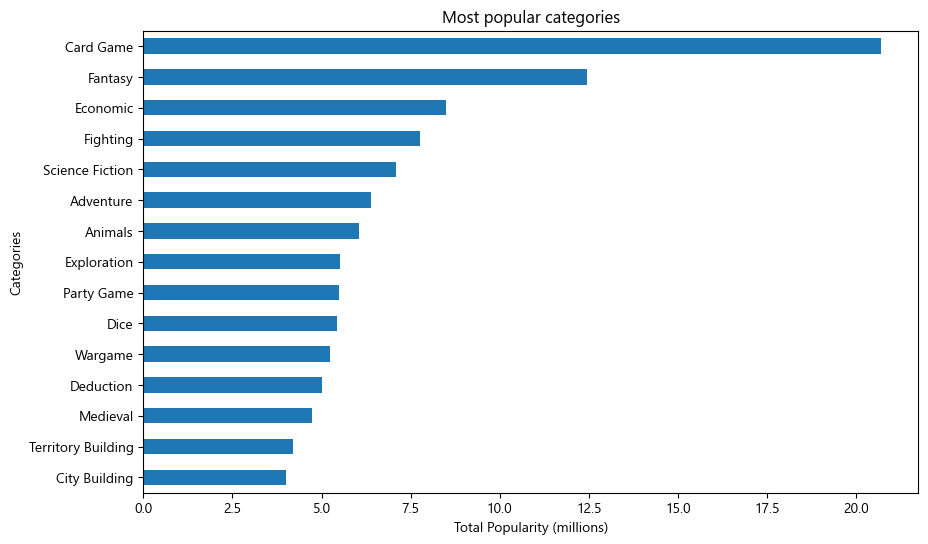

In [11]:
# Representación de las categorías en base a su popularidad:

top = games_df.explode("categories").groupby("categories")["popularidad_total"].sum().sort_values(ascending=False).head(15)/1000000

top.plot(kind="barh", figsize=(10,6))
plt.gca().invert_yaxis()
plt.title("Most popular categories")
plt.xlabel("Total Popularity (millions)")
plt.ylabel("Categories")
plt.show()
plt.rcParams["font.family"] = "Segoe UI"

### Para no perder de vista el rating, vamos a quedarnos solo con los juegos que tengan un número de ratings igual o mayor al tercer cuartil de los datos de boardgames solo con filtros (aprox. 460)

In [12]:
votings_selected = games_df[games_df["num_of_ratings"] > 460]

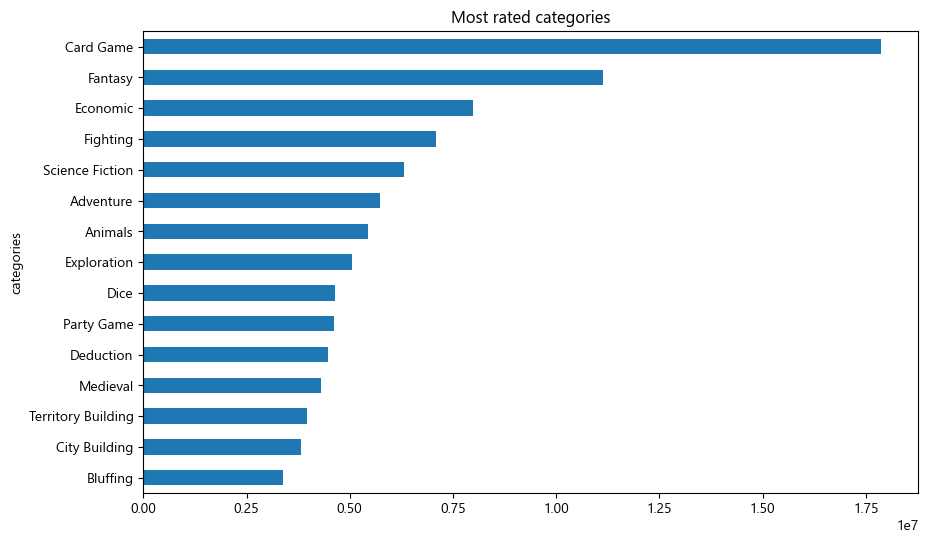

In [13]:
top = votings_selected.explode("categories").groupby("categories")["popularidad_total"].sum().sort_values(ascending=False).head(15)

top.plot(kind="barh", figsize=(10,6))
plt.gca().invert_yaxis()
plt.title("Most rated categories")
plt.show()
plt.rcParams["font.family"] = "Segoe UI"

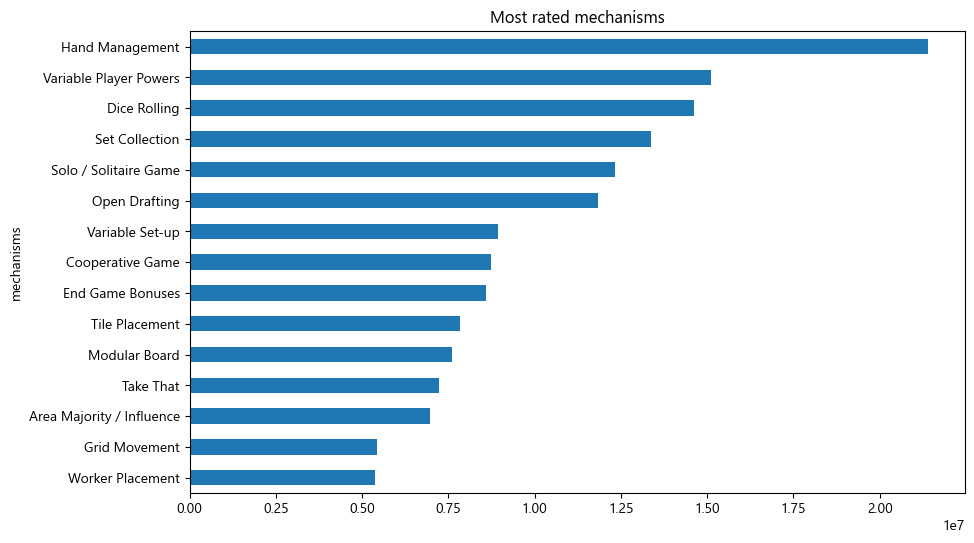

In [14]:
top = votings_selected.explode("mechanisms").groupby("mechanisms")["popularidad_total"].sum().sort_values(ascending=False).head(15)

top.plot(kind="barh", figsize=(10,6))
plt.gca().invert_yaxis()
plt.title("Most rated mechanisms")
plt.show()
plt.rcParams["font.family"] = "Segoe UI"

### Veamos la distribución de las edades

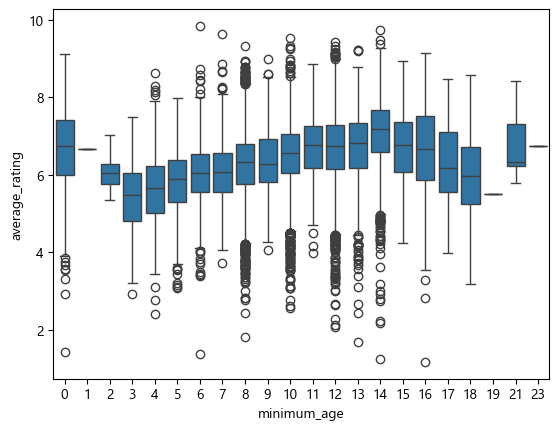

In [15]:
sns.boxplot(
    data=games_df,
    x="minimum_age",
    y="average_rating"
)

plt.show()

### **Sugerencia: Edad mínima para el producto de 11 (menor rango intercuartílico y putliers y mayor mediana) o 14 años (mayor mediana)**

### Veamos la distribución del rating en base al número mínimo y máximo de jugadores

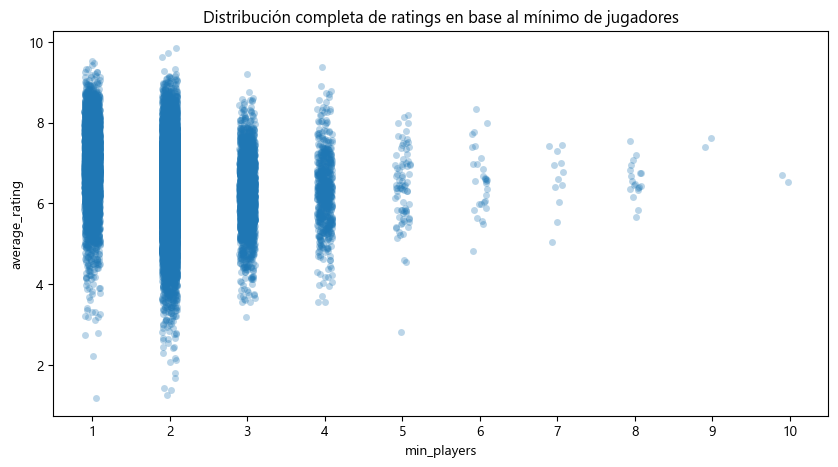

In [16]:
plt.figure(figsize=(10,5))

sns.stripplot(
    data=games_df,
    x="min_players",
    y="average_rating",
    jitter=True,
    alpha=0.3
)

plt.title("Distribución completa de ratings en base al mínimo de jugadores")
plt.show()

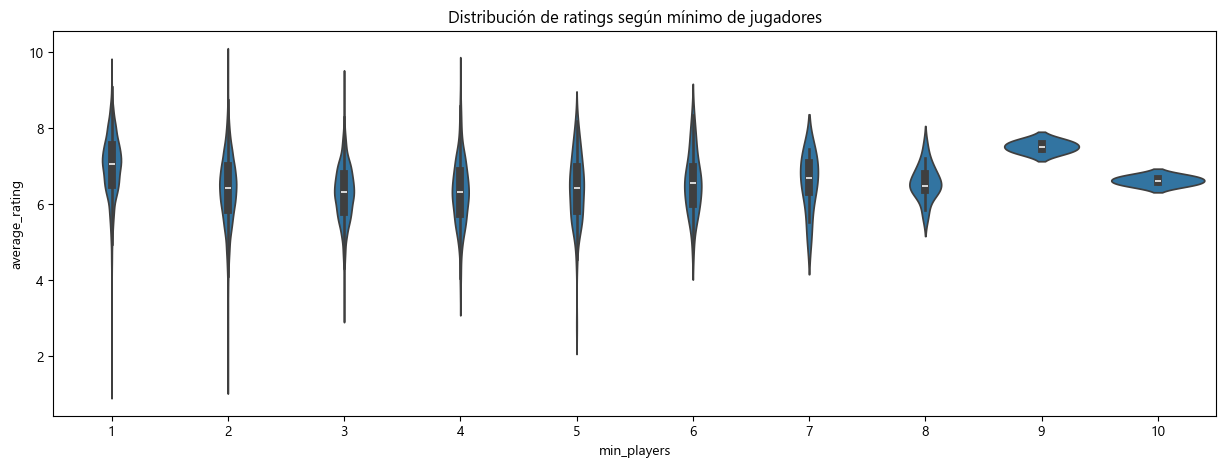

In [17]:
plt.figure(figsize=(15,5))

sns.violinplot(
    data=games_df,
    x="min_players",
    y="average_rating"
)

plt.title("Distribución de ratings según mínimo de jugadores")
plt.show()

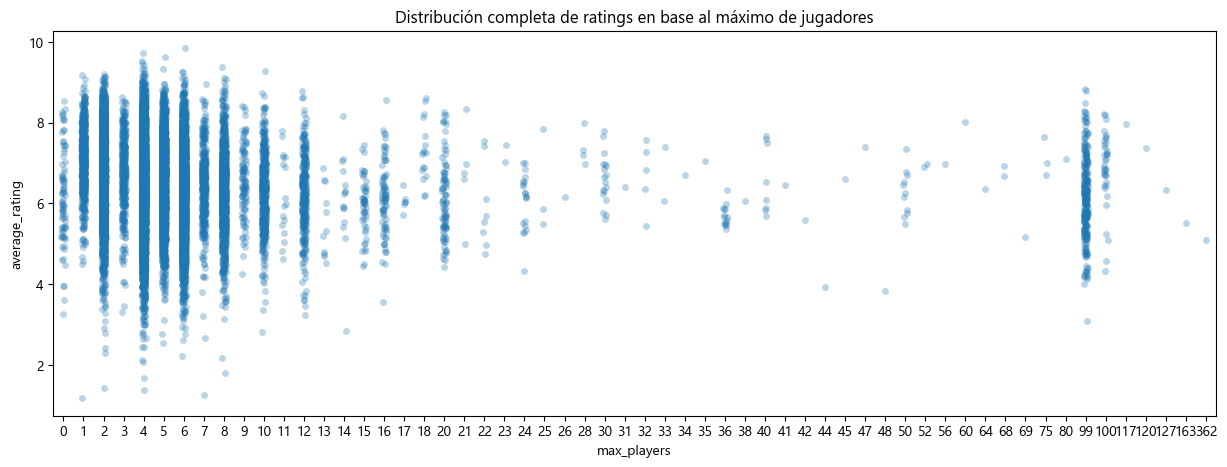

In [25]:
plt.figure(figsize=(15,5))

sns.stripplot(
    data=games_df,
    x="max_players",
    y="average_rating",
    jitter=True,
    alpha=0.3
)

plt.title("Distribución completa de ratings en base al máximo de jugadores")
plt.show()

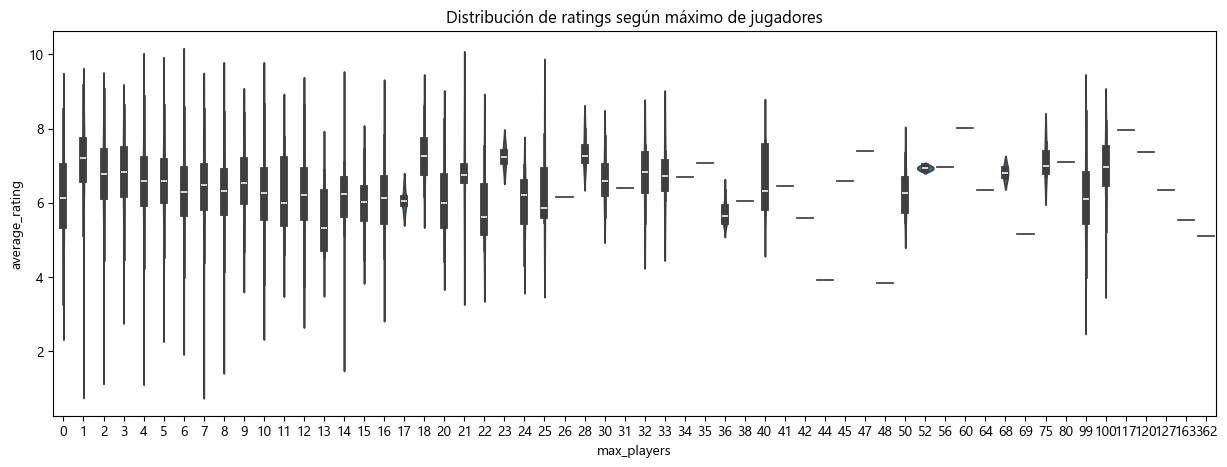

In [26]:
plt.figure(figsize=(15,5))

sns.violinplot(
    data=games_df,
    x="max_players",
    y="average_rating"
)

plt.title("Distribución de ratings según máximo de jugadores")
plt.show()

# Elegir al mejor diseñador y mejor artista

### **Sugerencias: Las categorías que aprecen ser más acertadas son Economic, Card Game, Fantasy, mientras que las mecánicas más interesantes/populares/frecuentes/mejor votadas son Dice rolling, Hand management y variable player powers. Usaría esas condiciones para modificar el código de abajo y sacar a los mejores artistas y a los mejores diseñadores. Se puede hacer en paralelo para los tres "tipos" de tabla filtrada (100 interés, 100 rating y filtros base) para ver si hay coincidencias**

In [1]:
# Adaptar el código para las categorías y mecanismos elegidos finalmente.

df_exp = games_df.explode("categories").explode("artists")

mecanica = ["Civilization", "Territory Building", "Space Exploration", "Science Fiction"]

df_mech = df_exp[df_exp["categories"].isin(mecanica)]

ranking = (
    df_mech
    .groupby(["categories", "artists"])["average_rating"]
    .mean()
    .reset_index()
)

best_designers = ranking.loc[
    ranking.groupby("categories")["average_rating"].idxmax()
]

best_designers.sort_values("categories")

NameError: name 'games_df' is not defined